# To explore correlation between no. packets reliably received in time window versus measured reliability (1) in time window <br>
Date: 16/10/2024

# For All Runs In An Interference Scenario

## Compile Data

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import glob, os
from tqdm import tqdm
from multiprocessing.pool import Pool

NUM_PROCS = 32
DATASET_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_uav_interference/uav_scenario_0_processed_tw2" 
scenario_paths = [x[0] for x in os.walk(DATASET_PATH) if (os.path.isdir(x[0]) and x[0]!=DATASET_PATH)]

# We normalize the no. reliable packets per time window with different maximum based on USI
usi_max_num_reliable_dl = {10: 50, 20: 50, 66.7: 50, 100: 50}
usi_max_num_reliable_ul = {10: 800, 20: 401, 66.7: 120, 100: 80}
usi_max_num_reliable_vid = {10: 173, 20: 173, 66.7: 173, 100: 173}

# Min to filter samples below threshold
usi_min_num_reliable_dl = {10: 50, 20: 50, 66.7: 50, 100: 50}
usi_min_num_reliable_ul = {10: 772, 20: 388, 66.7: 118, 100: 80}
usi_min_num_reliable_vid = {10: 172, 20: 172, 66.7: 172, 100: 172}

'''Without Filtering for Num_Reliable Above Threshold'''
def load_num_reliable(scenario_path):
    '''Modified: Add the scenario parameters and run number so that DFs can be sorted for rows 
                 of each DF to correspond to the same time window of the same run
    '''
    scenario_name = scenario_path.split("/")[-1]
    params = scenario_name.split("_")
    usi = [x for x in params if "UAVSendingInterval" in x][0].split('-')[-1]
    speed = [x for x in params if "UAVSpeed" in x][0].split('-')[-1]
    height = [x for x in params if "Height" in x][0].split('-')[-1]
    bitrate = [x for x in params if "BitRate" in x][0].split('-')[-1]

    # Get Run Nums (Using UL files, since there's only one UL file per run)
    ul_num_reliable_files = glob.glob(os.path.join(scenario_path, "Run-*_Uplink_Throughput.csv"))
    run_num = [int(f.split("Run-")[-1].split("_")[0]) for f in ul_num_reliable_files]
    # Load DL Throughput
    uav_df_list = []
    for run in run_num:
        dl_df_0 = pd.read_csv(os.path.join(scenario_path, "Run-{}_UAV-0_Downlink_Throughput.csv".format(run)))
        dl_df_1 = pd.read_csv(os.path.join(scenario_path, "Run-{}_UAV-1_Downlink_Throughput.csv".format(run)))
        dl_df_2 = pd.read_csv(os.path.join(scenario_path, "Run-{}_UAV-2_Downlink_Throughput.csv".format(run)))
        dl_df_3 = pd.read_csv(os.path.join(scenario_path, "Run-{}_UAV-3_Downlink_Throughput.csv".format(run)))
        dl_df_4 = pd.read_csv(os.path.join(scenario_path, "Run-{}_UAV-4_Downlink_Throughput.csv".format(run)))
        dl_df_5 = pd.read_csv(os.path.join(scenario_path, "Run-{}_UAV-5_Downlink_Throughput.csv".format(run)))
        dl_df_6 = pd.read_csv(os.path.join(scenario_path, "Run-{}_UAV-6_Downlink_Throughput.csv".format(run)))
        dl_df_7 = pd.read_csv(os.path.join(scenario_path, "Run-{}_UAV-7_Downlink_Throughput.csv".format(run)))
        for df in [dl_df_0, dl_df_1, dl_df_2, dl_df_3, dl_df_4, dl_df_5, dl_df_6, dl_df_7]:
            df["Run_Num"] = run
            df["USI"] = usi
            df["UAV_Speed"] = speed
            df["UAV_Height"] = height
            df["Bit_Rate"] = bitrate
        uav_df_list.append([dl_df_0, dl_df_1, dl_df_2, dl_df_3, dl_df_4, dl_df_5, dl_df_6, dl_df_7])
    dl_df_list = [pd.concat([uav_df_list[i][j] for i in range(len(run_num))]) for j in range(len(uav_df_list[0]))]
    
    # Load UL Throughput
    ul_df_list = []
    for run in run_num:
        measured_df = pd.read_csv(os.path.join(scenario_path, "Run-{}_Uplink_Throughput.csv".format(run)))
        measured_df["Run_Num"] = run
        ul_df_list.append(measured_df)
    ul_df = pd.concat(ul_df_list)
    ul_df["USI"] = usi
    ul_df["UAV_Speed"] = speed
    ul_df["UAV_Height"] = height
    ul_df["Bit_Rate"] = bitrate
    # Load Video Throughput
    vid_df_list = []
    for run in run_num:
        measured_df = pd.read_csv(os.path.join(scenario_path, "Run-{}_Video_Throughput.csv".format(run)))
        measured_df["Run_Num"] = run
        vid_df_list.append(measured_df)
    vid_df = pd.concat(vid_df_list)
    vid_df["USI"] = usi
    vid_df["UAV_Speed"] = speed
    vid_df["UAV_Height"] = height
    vid_df["Bit_Rate"] = bitrate

    return (dl_df_list, ul_df, vid_df)

'''With Filtering of Throughput Above Threshold'''
# def load_num_reliable(scenario_path, max_num_reliable_dl, max_num_reliable_ul, max_num_reliable_vid, min_num_reliable_dl, min_num_reliable_ul, min_num_reliable_vid):
#     # print(scenario_path.split("/")[-1])
#     # Load DL Throughput
#     dl_df_list = []
#     dl_num_reliable_files = glob.glob(os.path.join(scenario_path, "Run-*_Downlink_Throughput.csv"))
#     for file in dl_num_reliable_files:
#         measured_df = pd.read_csv(file)
#         dl_df_list.append(measured_df)
#     dl_df = pd.concat(dl_df_list)
#     # dl_df = dl_df.loc[dl_df["Num_Reliable"] < min_num_reliable_dl]
#     dl_df["Norm_Num_Reliable"] = dl_df["Num_Reliable"] / min_num_reliable_dl
#     # Load UL Throughput
#     ul_df_list = []
#     ul_num_reliable_files = glob.glob(os.path.join(scenario_path, "Run-*_Uplink_Throughput.csv"))
#     for file in ul_num_reliable_files:
#         measured_df = pd.read_csv(file)
#         ul_df_list.append(measured_df)
#     ul_df = pd.concat(ul_df_list)
#     # ul_df = ul_df.loc[ul_df["Num_Reliable"] < min_num_reliable_ul]
#     ul_df["Norm_Num_Reliable"] = ul_df["Num_Reliable"] / min_num_reliable_ul
#     # Load Video Throughput
#     vid_df_list = []
#     vid_num_reliable_files = glob.glob(os.path.join(scenario_path, "Run-*_Video_Throughput.csv"))
#     for file in vid_num_reliable_files:
#         measured_df = pd.read_csv(file)
#         vid_df_list.append(measured_df)
#     vid_df = pd.concat(vid_df_list)
#     # vid_df = vid_df.loc[vid_df["Num_Reliable"] < min_num_reliable_vid]
#     vid_df["Norm_Num_Reliable"] = vid_df["Num_Reliable"] / min_num_reliable_vid

#     return (dl_df, ul_df, vid_df)

# max_num_reliable_dl = []
# max_num_reliable_ul = []
# max_num_reliable_vid = []
# min_num_reliable_dl = []
# min_num_reliable_ul = []
# min_num_reliable_vid = []
# for scenario in scenario_paths:
#     scenario_params = scenario.split('_')
#     uav_sending_interval = float([param for param in scenario_params if "UAVSendingInterval-" in param][0].split('-')[-1])
#     max_num_reliable_dl.append(usi_max_num_reliable_dl[uav_sending_interval])
#     max_num_reliable_ul.append(usi_max_num_reliable_ul[uav_sending_interval])
#     max_num_reliable_vid.append(usi_max_num_reliable_vid[uav_sending_interval])
#     min_num_reliable_dl.append(usi_min_num_reliable_dl[uav_sending_interval]*2)
#     min_num_reliable_ul.append(usi_min_num_reliable_ul[uav_sending_interval]*2)
#     min_num_reliable_vid.append(usi_min_num_reliable_vid[uav_sending_interval]*2)

dl_num_reliable_df_list = []
ul_num_reliable_df_list = []
vid_num_reliable_df_list = []
with Pool(NUM_PROCS) as pool:
    for result in pool.starmap(load_num_reliable, zip(scenario_paths)):
    # for result in pool.starmap(load_num_reliable, zip(scenario_paths, max_num_reliable_dl, max_num_reliable_ul, max_num_reliable_vid)):
    # for result in pool.starmap(load_num_reliable, zip(scenario_paths, max_num_reliable_dl, max_num_reliable_ul, max_num_reliable_vid, min_num_reliable_dl, min_num_reliable_ul, min_num_reliable_vid)):
        dl_num_reliable_df_list.append(result[0])
        ul_num_reliable_df_list.append(result[1])
        vid_num_reliable_df_list.append(result[2])

uavs_num_reliable_df = [pd.concat([dl_num_reliable_df_list[i][j] for i in range(len(scenario_paths))]) for j in range(len(dl_num_reliable_df_list[0]))]           
uav_0_num_reliable_df = uavs_num_reliable_df[0]
uav_1_num_reliable_df = uavs_num_reliable_df[1]
uav_2_num_reliable_df = uavs_num_reliable_df[2]
uav_3_num_reliable_df = uavs_num_reliable_df[3]
uav_4_num_reliable_df = uavs_num_reliable_df[4]
uav_5_num_reliable_df = uavs_num_reliable_df[5]
uav_6_num_reliable_df = uavs_num_reliable_df[6]
uav_7_num_reliable_df = uavs_num_reliable_df[7]
ul_num_reliable_df = pd.concat(ul_num_reliable_df_list)
vid_num_reliable_df = pd.concat(vid_num_reliable_df_list)

# There could be some datapoints with 0 throughput and nan measured reliability
uav_0_num_reliable_df.dropna(subset=["Measured_Reliability_1", "Num_Reliable"], inplace=True)
uav_1_num_reliable_df.dropna(subset=["Measured_Reliability_1", "Num_Reliable"], inplace=True)
uav_2_num_reliable_df.dropna(subset=["Measured_Reliability_1", "Num_Reliable"], inplace=True)
uav_3_num_reliable_df.dropna(subset=["Measured_Reliability_1", "Num_Reliable"], inplace=True)
uav_4_num_reliable_df.dropna(subset=["Measured_Reliability_1", "Num_Reliable"], inplace=True)
uav_5_num_reliable_df.dropna(subset=["Measured_Reliability_1", "Num_Reliable"], inplace=True)
uav_6_num_reliable_df.dropna(subset=["Measured_Reliability_1", "Num_Reliable"], inplace=True)
uav_7_num_reliable_df.dropna(subset=["Measured_Reliability_1", "Num_Reliable"], inplace=True)
ul_num_reliable_df.dropna(subset=["Measured_Reliability_1", "Num_Reliable"], inplace=True)
vid_num_reliable_df.dropna(subset=["Measured_Reliability_1", "Num_Reliable"], inplace=True)

# Filter samples with "Time" < 1
uav_0_num_reliable_df = uav_0_num_reliable_df.loc[uav_0_num_reliable_df["Time"] >= 1]
uav_1_num_reliable_df = uav_1_num_reliable_df.loc[uav_1_num_reliable_df["Time"] >= 1]
uav_2_num_reliable_df = uav_2_num_reliable_df.loc[uav_2_num_reliable_df["Time"] >= 1]
uav_3_num_reliable_df = uav_3_num_reliable_df.loc[uav_3_num_reliable_df["Time"] >= 1]
uav_4_num_reliable_df = uav_4_num_reliable_df.loc[uav_4_num_reliable_df["Time"] >= 1]
uav_5_num_reliable_df = uav_5_num_reliable_df.loc[uav_5_num_reliable_df["Time"] >= 1]
uav_6_num_reliable_df = uav_6_num_reliable_df.loc[uav_6_num_reliable_df["Time"] >= 1]
uav_7_num_reliable_df = uav_7_num_reliable_df.loc[uav_7_num_reliable_df["Time"] >= 1]
ul_num_reliable_df = ul_num_reliable_df.loc[ul_num_reliable_df["Time"] >= 1]
vid_num_reliable_df = vid_num_reliable_df.loc[vid_num_reliable_df["Time"] >= 1]

KeyboardInterrupt: 

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import glob, os
from tqdm import tqdm
from multiprocessing.pool import Pool

uav_0_num_reliable_df = pd.read_csv("/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_uav_interference/uav_scenario_0_UAV_0_processed.csv")
uav_1_num_reliable_df = pd.read_csv("/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_uav_interference/uav_scenario_0_UAV_1_processed.csv")
uav_2_num_reliable_df = pd.read_csv("/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_uav_interference/uav_scenario_0_UAV_2_processed.csv")
uav_3_num_reliable_df = pd.read_csv("/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_uav_interference/uav_scenario_0_UAV_3_processed.csv")
uav_4_num_reliable_df = pd.read_csv("/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_uav_interference/uav_scenario_0_UAV_4_processed.csv")
uav_5_num_reliable_df = pd.read_csv("/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_uav_interference/uav_scenario_0_UAV_5_processed.csv")
uav_6_num_reliable_df = pd.read_csv("/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_uav_interference/uav_scenario_0_UAV_6_processed.csv")
uav_7_num_reliable_df = pd.read_csv("/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_uav_interference/uav_scenario_0_UAV_7_processed.csv")
ul_num_reliable_df = pd.read_csv("/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_uav_interference/uav_scenario_0_ul_processed.csv")
vid_num_reliable_df = pd.read_csv("/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_uav_interference/uav_scenario_0_vid_processed.csv")

# There could be some datapoints with 0 throughput and nan measured reliability
uav_0_num_reliable_df.dropna(subset=["Measured_Reliability_1", "Num_Reliable"], inplace=True)
uav_1_num_reliable_df.dropna(subset=["Measured_Reliability_1", "Num_Reliable"], inplace=True)
uav_2_num_reliable_df.dropna(subset=["Measured_Reliability_1", "Num_Reliable"], inplace=True)
uav_3_num_reliable_df.dropna(subset=["Measured_Reliability_1", "Num_Reliable"], inplace=True)
uav_4_num_reliable_df.dropna(subset=["Measured_Reliability_1", "Num_Reliable"], inplace=True)
uav_5_num_reliable_df.dropna(subset=["Measured_Reliability_1", "Num_Reliable"], inplace=True)
uav_6_num_reliable_df.dropna(subset=["Measured_Reliability_1", "Num_Reliable"], inplace=True)
uav_7_num_reliable_df.dropna(subset=["Measured_Reliability_1", "Num_Reliable"], inplace=True)
ul_num_reliable_df.dropna(subset=["Measured_Reliability_1", "Num_Reliable"], inplace=True)
vid_num_reliable_df.dropna(subset=["Measured_Reliability_1", "Num_Reliable"], inplace=True)

# Filter samples with "Time" < 1
uav_0_num_reliable_df = uav_0_num_reliable_df.loc[uav_0_num_reliable_df["Time"] >= 1]
uav_1_num_reliable_df = uav_1_num_reliable_df.loc[uav_1_num_reliable_df["Time"] >= 1]
uav_2_num_reliable_df = uav_2_num_reliable_df.loc[uav_2_num_reliable_df["Time"] >= 1]
uav_3_num_reliable_df = uav_3_num_reliable_df.loc[uav_3_num_reliable_df["Time"] >= 1]
uav_4_num_reliable_df = uav_4_num_reliable_df.loc[uav_4_num_reliable_df["Time"] >= 1]
uav_5_num_reliable_df = uav_5_num_reliable_df.loc[uav_5_num_reliable_df["Time"] >= 1]
uav_6_num_reliable_df = uav_6_num_reliable_df.loc[uav_6_num_reliable_df["Time"] >= 1]
uav_7_num_reliable_df = uav_7_num_reliable_df.loc[uav_7_num_reliable_df["Time"] >= 1]
ul_num_reliable_df = ul_num_reliable_df.loc[ul_num_reliable_df["Time"] >= 1]
vid_num_reliable_df = vid_num_reliable_df.loc[vid_num_reliable_df["Time"] >= 1]


In [4]:
# Split UL by USI
ul_nr_usi_10_df = ul_num_reliable_df.loc[ul_num_reliable_df["USI"] == 10]
ul_nr_usi_20_df = ul_num_reliable_df.loc[ul_num_reliable_df["USI"] == 20]
ul_nr_usi_667_df = ul_num_reliable_df.loc[ul_num_reliable_df["USI"] == 66.7]
ul_nr_usi_100_df = ul_num_reliable_df.loc[ul_num_reliable_df["USI"] == 100]

In [5]:
# Drop Duplicates
uav_0_num_reliable_df = uav_0_num_reliable_df.drop_duplicates(subset=["Num_Reliable", "Measured_Reliability_1"])
uav_1_num_reliable_df = uav_0_num_reliable_df.drop_duplicates(subset=["Num_Reliable", "Measured_Reliability_1"])
uav_2_num_reliable_df = uav_0_num_reliable_df.drop_duplicates(subset=["Num_Reliable", "Measured_Reliability_1"])
uav_3_num_reliable_df = uav_0_num_reliable_df.drop_duplicates(subset=["Num_Reliable", "Measured_Reliability_1"])
uav_4_num_reliable_df = uav_0_num_reliable_df.drop_duplicates(subset=["Num_Reliable", "Measured_Reliability_1"])
uav_5_num_reliable_df = uav_0_num_reliable_df.drop_duplicates(subset=["Num_Reliable", "Measured_Reliability_1"])
uav_6_num_reliable_df = uav_0_num_reliable_df.drop_duplicates(subset=["Num_Reliable", "Measured_Reliability_1"])
uav_7_num_reliable_df = uav_0_num_reliable_df.drop_duplicates(subset=["Num_Reliable", "Measured_Reliability_1"])
ul_nr_usi_10_df = ul_nr_usi_10_df.drop_duplicates(subset=["Num_Reliable", "Measured_Reliability_1"])
ul_nr_usi_20_df = ul_nr_usi_20_df.drop_duplicates(subset=["Num_Reliable", "Measured_Reliability_1"])
ul_nr_usi_667_df = ul_nr_usi_667_df.drop_duplicates(subset=["Num_Reliable", "Measured_Reliability_1"])
ul_nr_usi_100_df = ul_nr_usi_100_df.drop_duplicates(subset=["Num_Reliable", "Measured_Reliability_1"])

## Check for Normality

In [9]:
# D-Agostino Test
from scipy import stats

ul_nr_usi_10_normal = stats.normaltest(ul_nr_usi_10_df["Num_Reliable"].values)
ul_nr_usi_20_normal = stats.normaltest(ul_nr_usi_20_df["Num_Reliable"].values)
ul_nr_usi_667_normal = stats.normaltest(ul_nr_usi_667_df["Num_Reliable"].values)
ul_nr_usi_100_normal = stats.normaltest(ul_nr_usi_100_df["Num_Reliable"].values)

uav_0_nr_normal = stats.normaltest(uav_0_num_reliable_df["Num_Reliable"].values)
uav_1_nr_normal = stats.normaltest(uav_1_num_reliable_df["Num_Reliable"].values)
uav_2_nr_normal = stats.normaltest(uav_2_num_reliable_df["Num_Reliable"].values)
uav_3_nr_normal = stats.normaltest(uav_3_num_reliable_df["Num_Reliable"].values)
uav_4_nr_normal = stats.normaltest(uav_4_num_reliable_df["Num_Reliable"].values)
uav_5_nr_normal = stats.normaltest(uav_5_num_reliable_df["Num_Reliable"].values)
uav_6_nr_normal = stats.normaltest(uav_6_num_reliable_df["Num_Reliable"].values)
uav_7_nr_normal = stats.normaltest(uav_7_num_reliable_df["Num_Reliable"].values)

print(ul_nr_usi_10_normal)
print(ul_nr_usi_20_normal)
print(ul_nr_usi_667_normal)
print(ul_nr_usi_100_normal)
print(uav_0_nr_normal)
print(uav_1_nr_normal)
print(uav_2_nr_normal)
print(uav_3_nr_normal)
print(uav_4_nr_normal)
print(uav_5_nr_normal)
print(uav_6_nr_normal)
print(uav_7_nr_normal)

NormaltestResult(statistic=23032.682290410427, pvalue=0.0)
NormaltestResult(statistic=10455.689222955049, pvalue=0.0)
NormaltestResult(statistic=227.36693653473, pvalue=4.245189172341501e-50)
NormaltestResult(statistic=57.057367308083684, pvalue=4.0752111238347174e-13)
NormaltestResult(statistic=420.9119992989546, pvalue=3.982178000704e-92)
NormaltestResult(statistic=420.9119992989546, pvalue=3.982178000704e-92)
NormaltestResult(statistic=420.9119992989546, pvalue=3.982178000704e-92)
NormaltestResult(statistic=420.9119992989546, pvalue=3.982178000704e-92)
NormaltestResult(statistic=420.9119992989546, pvalue=3.982178000704e-92)
NormaltestResult(statistic=420.9119992989546, pvalue=3.982178000704e-92)
NormaltestResult(statistic=420.9119992989546, pvalue=3.982178000704e-92)
NormaltestResult(statistic=420.9119992989546, pvalue=3.982178000704e-92)


## Calculate Correlation Metric

### Aggregate USI for UL, Aggregate UAVs for DL

In [24]:
# For all runs

from scipy import stats

# Pearson Rho
pearsonr_dl = stats.pearsonr(dl_num_reliable_df["Norm_Num_Reliable"].values, dl_num_reliable_df["Measured_Reliability_1"].values)
pearsonr_ul = stats.pearsonr(ul_num_reliable_df["Norm_Num_Reliable"].values, ul_num_reliable_df["Measured_Reliability_1"].values)
pearsonr_vid = stats.pearsonr(vid_num_reliable_df["Norm_Num_Reliable"].values, vid_num_reliable_df["Measured_Reliability_1"].values)

# Spearman Rho
spearmanr_dl = stats.spearmanr(dl_num_reliable_df["Norm_Num_Reliable"].values, dl_num_reliable_df["Measured_Reliability_1"].values)
spearmanr_ul = stats.spearmanr(ul_num_reliable_df["Norm_Num_Reliable"].values, ul_num_reliable_df["Measured_Reliability_1"].values)
spearmanr_vid = stats.spearmanr(vid_num_reliable_df["Norm_Num_Reliable"].values, vid_num_reliable_df["Measured_Reliability_1"].values)

# Kendall Tau
kd_dl = stats.kendalltau(dl_num_reliable_df["Norm_Num_Reliable"].values, dl_num_reliable_df["Measured_Reliability_1"].values)
kd_ul = stats.kendalltau(ul_num_reliable_df["Norm_Num_Reliable"].values, ul_num_reliable_df["Measured_Reliability_1"].values)
kd_vid = stats.kendalltau(vid_num_reliable_df["Norm_Num_Reliable"].values, vid_num_reliable_df["Measured_Reliability_1"].values)

print("Pearson Correlation - DL: {}, UL: {}, VID: {}".format(pearsonr_dl[0], pearsonr_ul[0], pearsonr_vid[0]))
print("Spearman Correlation - DL: {}, UL: {}, VID: {}".format(spearmanr_dl.correlation, spearmanr_ul.correlation, spearmanr_vid.correlation))
print("Kendall Tau Correlation - DL: {}, UL: {}, VID: {}".format(kd_dl.correlation, kd_ul.correlation, kd_vid.correlation))

print("Pearson P Value - DL: {}, UL: {}, VID: {}".format(pearsonr_dl[1], pearsonr_ul[1], pearsonr_vid[1]))
print("Spearman P Value - DL: {}, UL: {}, VID: {}".format(spearmanr_dl.pvalue, spearmanr_ul.pvalue, spearmanr_vid.pvalue))
print("Kendall Tau P Value - DL: {}, UL: {}, VID: {}".format(kd_dl.pvalue, kd_ul.pvalue, kd_vid.pvalue))

/home/research-student/.local/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4868: RuntimeWarning: overflow encountered in long_scalars
  (2 * xtie * ytie) / m + x0 * y0 / (9 * m * (size - 2)))


Pearson Correlation - DL: 0.9997957303459869, UL: 0.999545464067787, VID: 0.9944029681709596
Spearman Correlation - DL: 0.9914310909704067, UL: 0.6269206393135213, VID: 0.7269717156603147
Kendall Tau Correlation - DL: 0.9886314756222447, UL: 0.5610608820193611, VID: 0.6994523314172686
Pearson P Value - DL: 0.0, UL: 0.0, VID: 0.0
Spearman P Value - DL: 0.0, UL: 0.0, VID: 0.0
Kendall Tau P Value - DL: 0.0, UL: 0.0, VID: 0.0


### Considering Different USI and Individual UAVs separately

In [10]:
# For all runs

from scipy import stats

# Spearman Rho
spearmanr_uav_0 = stats.spearmanr(uav_0_num_reliable_df["Num_Reliable"].values, uav_0_num_reliable_df["Measured_Reliability_1"].values)
spearmanr_uav_1 = stats.spearmanr(uav_1_num_reliable_df["Num_Reliable"].values, uav_1_num_reliable_df["Measured_Reliability_1"].values)
spearmanr_uav_2 = stats.spearmanr(uav_2_num_reliable_df["Num_Reliable"].values, uav_2_num_reliable_df["Measured_Reliability_1"].values)
spearmanr_uav_3 = stats.spearmanr(uav_3_num_reliable_df["Num_Reliable"].values, uav_3_num_reliable_df["Measured_Reliability_1"].values)
spearmanr_uav_4 = stats.spearmanr(uav_4_num_reliable_df["Num_Reliable"].values, uav_4_num_reliable_df["Measured_Reliability_1"].values)
spearmanr_uav_5 = stats.spearmanr(uav_5_num_reliable_df["Num_Reliable"].values, uav_5_num_reliable_df["Measured_Reliability_1"].values)
spearmanr_uav_6 = stats.spearmanr(uav_6_num_reliable_df["Num_Reliable"].values, uav_6_num_reliable_df["Measured_Reliability_1"].values)
spearmanr_uav_7 = stats.spearmanr(uav_7_num_reliable_df["Num_Reliable"].values, uav_7_num_reliable_df["Measured_Reliability_1"].values)
ul_nr_usi_10_df = ul_num_reliable_df.loc[ul_num_reliable_df["USI"] == 10]
ul_nr_usi_20_df = ul_num_reliable_df.loc[ul_num_reliable_df["USI"] == 20]
ul_nr_usi_667_df = ul_num_reliable_df.loc[ul_num_reliable_df["USI"] == 66.7]
ul_nr_usi_100_df = ul_num_reliable_df.loc[ul_num_reliable_df["USI"] == 100]
spearmanr_ul_usi_10 = stats.spearmanr(ul_nr_usi_10_df["Num_Reliable"].values, ul_nr_usi_10_df["Measured_Reliability_1"].values)
spearmanr_ul_usi_20 = stats.spearmanr(ul_nr_usi_20_df["Num_Reliable"].values, ul_nr_usi_20_df["Measured_Reliability_1"].values)
spearmanr_ul_usi_667 = stats.spearmanr(ul_nr_usi_667_df["Num_Reliable"].values, ul_nr_usi_667_df["Measured_Reliability_1"].values)
spearmanr_ul_usi_100 = stats.spearmanr(ul_nr_usi_100_df["Num_Reliable"].values, ul_nr_usi_100_df["Measured_Reliability_1"].values)
spearmanr_vid = stats.spearmanr(vid_num_reliable_df["Num_Reliable"].values, vid_num_reliable_df["Measured_Reliability_1"].values)

print("Spearman Correlation DL - UAV 0: {}, UAV 1: {}, UAV 2: {}, UAV 3: {}, UAV 4: {}, UAV 5: {}, UAV 6: {}, UAV 7: {},".format(
    spearmanr_uav_0.correlation, spearmanr_uav_1.correlation, spearmanr_uav_2.correlation, spearmanr_uav_3.correlation,
    spearmanr_uav_4.correlation, spearmanr_uav_5.correlation, spearmanr_uav_6.correlation, spearmanr_uav_7.correlation))
print("Spearman Correlation UL - USI 10: {}, USI 20: {}, USI 66.7: {}, USI 100: {}".format(spearmanr_ul_usi_10.correlation, spearmanr_ul_usi_20.correlation, 
                                                                                           spearmanr_ul_usi_667.correlation, spearmanr_ul_usi_100.correlation))
print("Spearman Correlation VID: {}".format(spearmanr_vid.correlation))

print("Spearman P Value DL - UAV 0: {}, UAV 1: {}, UAV 2: {}, UAV 3: {}, UAV 4: {}, UAV 5: {}, UAV 6: {}, UAV 7: {},".format(
    spearmanr_uav_0.pvalue, spearmanr_uav_1.pvalue, spearmanr_uav_2.pvalue, spearmanr_uav_3.pvalue,
    spearmanr_uav_4.pvalue, spearmanr_uav_5.pvalue, spearmanr_uav_6.pvalue, spearmanr_uav_7.pvalue))
print("Spearman P Value UL - USI 10: {}, USI 20: {}, USI 66.7: {}, USI 100: {}".format(spearmanr_ul_usi_10.pvalue, spearmanr_ul_usi_20.pvalue, 
                                                                                           spearmanr_ul_usi_667.pvalue, spearmanr_ul_usi_100.pvalue))
print("Spearman P Value VID: {}".format(spearmanr_vid.pvalue))

Spearman Correlation DL - UAV 0: 0.9551318405645323, UAV 1: 0.9551318405645323, UAV 2: 0.9551318405645323, UAV 3: 0.9551318405645323, UAV 4: 0.9551318405645323, UAV 5: 0.9551318405645323, UAV 6: 0.9551318405645323, UAV 7: 0.9551318405645323,
Spearman Correlation UL - USI 10: 0.9971604103178168, USI 20: 0.9001095734618512, USI 66.7: 0.29095569029363133, USI 100: 0.9207021445685923
Spearman Correlation VID: 0.6641144401836139
Spearman P Value DL - UAV 0: 0.0, UAV 1: 0.0, UAV 2: 0.0, UAV 3: 0.0, UAV 4: 0.0, UAV 5: 0.0, UAV 6: 0.0, UAV 7: 0.0,
Spearman P Value UL - USI 10: 0.0, USI 20: 0.0, USI 66.7: 0.0, USI 100: 0.0
Spearman P Value VID: 0.0


## Plot Correlation

### Aggregate USI for UL, Aggregate UAVs for DL

In [21]:
seed = 1
dl_num_reliable_sample_df = dl_num_reliable_df.sample(n=100000, replace=False, random_state=seed)
ul_num_reliable_sample_df = ul_num_reliable_df.sample(n=100000, replace=False, random_state=seed)
vid_num_reliable_sample_df = vid_num_reliable_df.sample(n=100000, replace=False, random_state=seed)
# dl_num_reliable_sample_df = dl_num_reliable_df
# ul_num_reliable_sample_df = ul_num_reliable_df
# vid_num_reliable_sample_df = vid_num_reliable_df

In [1]:
# plt.figure(figsize=(10,6))
# plt.rcParams.update({'font.size': 14})
# plt.scatter(dl_num_reliable_sample_df["Norm_Num_Reliable"], dl_num_reliable_sample_df["Measured_Reliability_1"], c="k", alpha=0.05, linewidths=1)
# plt.ylabel("Reliability")
# plt.xlabel("'Normalized' $n_{r}$")
# # plt.xlim((0,1))
# plt.ylim((0,1.05))

# plt.figure(figsize=(10,6))
# plt.rcParams.update({'font.size': 14})
# plt.scatter(ul_num_reliable_sample_df["Norm_Num_Reliable"], ul_num_reliable_sample_df["Measured_Reliability_1"], c="k", alpha=0.05, linewidths=1)
# plt.ylabel("Reliability")
# plt.xlabel("'Normalized' $n_{r}$")
# plt.xlim((0,1.1))
# plt.ylim((0,1.05))

plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
plt.scatter(vid_num_reliable_sample_df["Norm_Num_Reliable"], vid_num_reliable_sample_df["Measured_Reliability_1"], c="k", alpha=0.006, linewidths=0.5)
plt.ylabel("Reliability")
plt.xlabel("'Normalized' $n_{r}$")
plt.xlim((0,1.2))
plt.ylim((0,1.05))

NameError: name 'plt' is not defined

### Considering Different USI and Individual UAVs separately

In [11]:
seed = 1
NUM_SAMPLES = 10000
if (len(uav_0_num_reliable_df)>NUM_SAMPLES):
    uav_0_sample_df = uav_0_num_reliable_df.sample(n=NUM_SAMPLES, replace=False, random_state=seed)
else:
    uav_0_sample_df = uav_0_num_reliable_df
if (len(uav_1_num_reliable_df)>NUM_SAMPLES):
    uav_1_sample_df = uav_1_num_reliable_df.sample(n=NUM_SAMPLES, replace=False, random_state=seed)
else:
    uav_1_sample_df = uav_1_num_reliable_df
if (len(uav_2_num_reliable_df)>NUM_SAMPLES):
    uav_2_sample_df = uav_2_num_reliable_df.sample(n=NUM_SAMPLES, replace=False, random_state=seed)
else:
    uav_2_sample_df = uav_2_num_reliable_df
if (len(uav_3_num_reliable_df)>NUM_SAMPLES):
    uav_3_sample_df = uav_3_num_reliable_df.sample(n=NUM_SAMPLES, replace=False, random_state=seed)
else:
    uav_3_sample_df = uav_3_num_reliable_df
if (len(uav_4_num_reliable_df)>NUM_SAMPLES):
    uav_4_sample_df = uav_4_num_reliable_df.sample(n=NUM_SAMPLES, replace=False, random_state=seed)
else:
    uav_4_sample_df = uav_4_num_reliable_df
if (len(uav_5_num_reliable_df)>NUM_SAMPLES):
    uav_5_sample_df = uav_5_num_reliable_df.sample(n=NUM_SAMPLES, replace=False, random_state=seed)
else:
    uav_5_sample_df = uav_5_num_reliable_df
if (len(uav_6_num_reliable_df)>NUM_SAMPLES):
    uav_6_sample_df = uav_6_num_reliable_df.sample(n=NUM_SAMPLES, replace=False, random_state=seed)
else:
    uav_6_sample_df = uav_6_num_reliable_df
if (len(uav_7_num_reliable_df)>NUM_SAMPLES):
    uav_7_sample_df = uav_7_num_reliable_df.sample(n=NUM_SAMPLES, replace=False, random_state=seed)
else:
    uav_7_sample_df = uav_7_num_reliable_df

if (len(ul_nr_usi_10_df)>NUM_SAMPLES):
    ul_usi_10_sample_df = ul_nr_usi_10_df.sample(n=NUM_SAMPLES, replace=False, random_state=seed)
else:
    ul_usi_10_sample_df = ul_nr_usi_10_df
if (len(ul_nr_usi_20_df)>NUM_SAMPLES):
    ul_usi_20_sample_df = ul_nr_usi_20_df.sample(n=NUM_SAMPLES, replace=False, random_state=seed)
else:
    ul_usi_20_sample_df = ul_nr_usi_20_df
if (len(ul_nr_usi_667_df)>NUM_SAMPLES):
    ul_usi_667_sample_df = ul_nr_usi_667_df.sample(n=NUM_SAMPLES, replace=False, random_state=seed)
else:
    ul_usi_667_sample_df = ul_nr_usi_667_df
if (len(ul_nr_usi_100_df)>NUM_SAMPLES):
    ul_usi_100_sample_df = ul_nr_usi_100_df.sample(n=NUM_SAMPLES, replace=False, random_state=seed)
else:
    ul_usi_100_sample_df = ul_nr_usi_100_df

if (len(vid_num_reliable_df)>NUM_SAMPLES):
    vid_sample_df = vid_num_reliable_df.sample(n=NUM_SAMPLES, replace=False, random_state=seed)
else:
    vid_sample_df = vid_num_reliable_df

(0.0, 1.05)

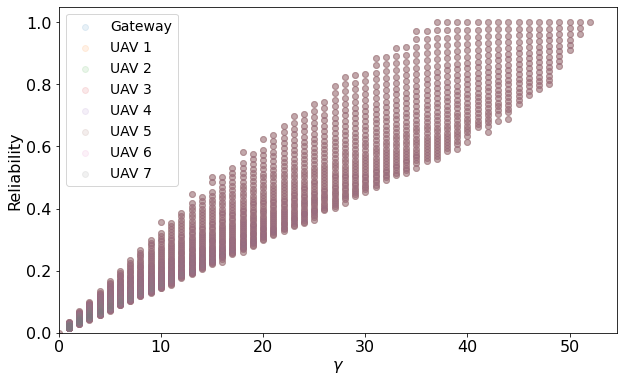

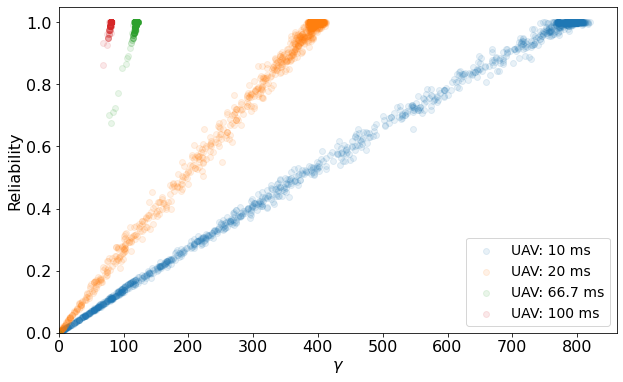

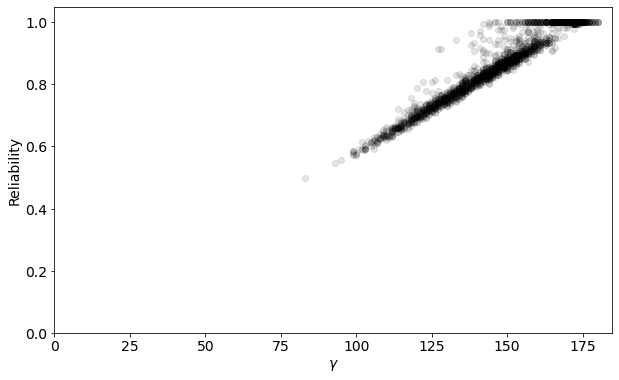

In [12]:
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 16})
plt.scatter(uav_0_sample_df["Num_Reliable"], uav_0_sample_df["Measured_Reliability_1"], c="tab:blue", alpha=0.1, linewidths=1, label="Gateway")
plt.scatter(uav_1_sample_df["Num_Reliable"], uav_1_sample_df["Measured_Reliability_1"], c="tab:orange", alpha=0.1, linewidths=1, label="UAV 1")
plt.scatter(uav_2_sample_df["Num_Reliable"], uav_2_sample_df["Measured_Reliability_1"], c="tab:green", alpha=0.1, linewidths=1, label="UAV 2")
plt.scatter(uav_3_sample_df["Num_Reliable"], uav_3_sample_df["Measured_Reliability_1"], c="tab:red", alpha=0.1, linewidths=1, label="UAV 3")
plt.scatter(uav_4_sample_df["Num_Reliable"], uav_4_sample_df["Measured_Reliability_1"], c="tab:purple", alpha=0.1, linewidths=1, label="UAV 4")
plt.scatter(uav_5_sample_df["Num_Reliable"], uav_5_sample_df["Measured_Reliability_1"], c="tab:brown", alpha=0.1, linewidths=1, label="UAV 5")
plt.scatter(uav_6_sample_df["Num_Reliable"], uav_6_sample_df["Measured_Reliability_1"], c="tab:pink", alpha=0.1, linewidths=1, label="UAV 6")
plt.scatter(uav_7_sample_df["Num_Reliable"], uav_7_sample_df["Measured_Reliability_1"], c="tab:gray", alpha=0.1, linewidths=1, label="UAV 7")
plt.ylabel("Reliability")
plt.xlabel("$\gamma$")
plt.xlim(left=0)
plt.ylim((0,1.05))
plt.legend(fontsize=14)

plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 16})
plt.scatter(ul_usi_10_sample_df["Num_Reliable"], ul_usi_10_sample_df["Measured_Reliability_1"], c="tab:blue", alpha=0.1, linewidths=1, label="UAV: 10 ms")
plt.scatter(ul_usi_20_sample_df["Num_Reliable"], ul_usi_20_sample_df["Measured_Reliability_1"], c="tab:orange", alpha=0.1, linewidths=1, label="UAV: 20 ms")
plt.scatter(ul_usi_667_sample_df["Num_Reliable"], ul_usi_667_sample_df["Measured_Reliability_1"], c="tab:green", alpha=0.1, linewidths=1, label="UAV: 66.7 ms")
plt.scatter(ul_usi_100_sample_df["Num_Reliable"], ul_usi_100_sample_df["Measured_Reliability_1"], c="tab:red", alpha=0.1, linewidths=1, label="UAV: 100 ms")
plt.ylabel("Reliability")
plt.xlabel("$\gamma$")
plt.xlim(left=0)
plt.ylim((0,1.05))
plt.legend(fontsize=14)

plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
plt.scatter(vid_sample_df["Num_Reliable"], vid_sample_df["Measured_Reliability_1"], c="k", alpha=0.1, linewidths=1)
plt.ylabel("Reliability")
plt.xlabel("$\gamma$")
plt.xlim(left=0)
plt.ylim((0,1.05))